Total valid rows: 9


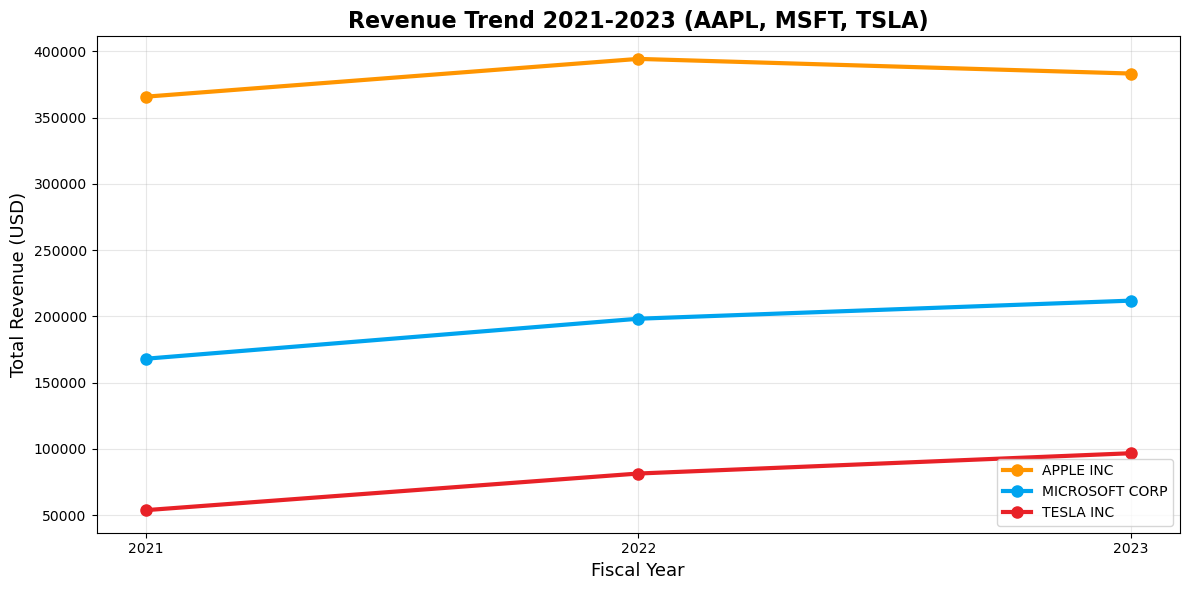

Financial Indicators:
             conm  fyear      revt       ni  profit_margin
0       APPLE INC   2021  365817.0  94680.0          25.88
1       APPLE INC   2022  394328.0  99803.0          25.31
2       APPLE INC   2023  383285.0  96995.0          25.31
3  MICROSOFT CORP   2021  168088.0  61271.0          36.45
4  MICROSOFT CORP   2022  198270.0  72738.0          36.69
5  MICROSOFT CORP   2023  211915.0  72361.0          34.15
6       TESLA INC   2021   53823.0   5519.0          10.25
7       TESLA INC   2022   81462.0  12556.0          15.41
8       TESLA INC   2023   96773.0  14997.0          15.50


In [1]:
# ACC102 Financial Analysis
# Companies: AAPL MSFT TSLA
# Period: 2021 - 2023

import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv("wrds_financial_data.csv")

# 2. Keep only necessary columns
df = df[["conm", "fyear", "revt", "ni"]].copy()

# 3. Data cleaning
df["revt"] = pd.to_numeric(df["revt"], errors="coerce")
df["ni"] = pd.to_numeric(df["ni"], errors="coerce")
df = df.dropna()

# 4. Filter data for 2021-2023
df = df[(df["fyear"] >= 2021) & (df["fyear"] <= 2023)]

print("Total valid rows:", len(df))

# 5. Calculate profit margin
df["profit_margin"] = (df["ni"] / df["revt"] * 100).round(2)

# 6. Create revenue trend plot
plt.figure(figsize=(12, 6), dpi=100)

colors = {
    "APPLE INC": "#FF9500",
    "MICROSOFT CORP": "#00A4EF",
    "TESLA INC": "#E82127"
}

for company in df["conm"].unique():
    cdf = df[df["conm"] == company].sort_values("fyear")
    plt.plot(
        cdf["fyear"], cdf["revt"], 
        marker="o", linewidth=3, markersize=8, 
        color=colors[company], label=company
    )

plt.title("Revenue Trend 2021-2023 (AAPL, MSFT, TSLA)", fontsize=16, weight='bold')
plt.xlabel("Fiscal Year", fontsize=13)
plt.ylabel("Total Revenue (USD)", fontsize=13)
plt.xticks([2021,2022,2023])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("revenue_trend.pdf", dpi=300, bbox_inches="tight")

plt.show()

# 7. Display final results
print("Financial Indicators:")
print(df.round(2))